# Guided Conditional Diffusion Training

This notebook uses `diffusion_hash_inv.models.guided_conditional_diffusion`, which implements classifier guidance and classifier-free guidance without changing the base `conditional_diffusion.py` pipeline.

Data mapping:
- input image: `data/images/<run-id>/message.png`
- condition label: `output/json/**/<run-id>.json` -> final hash when `LABEL_SOURCE="final-hash"`, otherwise `Logs/4th Step`

Guidance modes:
- `classifier-free`: trains one denoiser with random condition dropout and samples with `eps_uncond + guidance_scale * (eps_cond - eps_uncond)`.
- `classifier`: trains an unconditional denoiser plus a noisy-image classifier and samples with `grad_x log p(label | x_t)`.

## Imports

The path bootstrap lets the notebook run before `pip install -e .`; after installation, the package import path is used normally.

In [11]:
from dataclasses import asdict, replace
from pathlib import Path
import json
import sys


def add_local_src_to_path() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        src = candidate / "src"
        if (candidate / "pyproject.toml").exists() and (src / "diffusion_hash_inv").exists():
            if str(src) not in sys.path:
                sys.path.insert(0, str(src))
            return candidate
    raise RuntimeError("Project root with src/diffusion_hash_inv was not found.")


try:
    from diffusion_hash_inv.config import OutputConfig
except ModuleNotFoundError:
    add_local_src_to_path()
    from diffusion_hash_inv.config import OutputConfig

import torch
from IPython.display import display
from PIL import Image

from diffusion_hash_inv.models.conditional_diffusion import (
    GeneratedImageDataset,
    cleanup_torch_resources,
    save_image_grid,
)
from diffusion_hash_inv.models.guided_conditional_diffusion import (
    GuidedConditionalDiffusionTrainConfig,
    train_guided_conditional_diffusion,
)


## Project Paths And Mode

Both guidance modes in `GUIDANCE_MODES` are configured and can be run sequentially. Set `LABEL_SOURCE` to `final-hash` for the final-hash conditional model.

In [12]:
output_cfg = OutputConfig()

DATA_ROOT = output_cfg.data_dir / "images"
JSON_ROOT = output_cfg.output_dir / "json"
LABEL_SOURCE = "final-hash"  # use "step4" for the existing Logs/4th Step labels
GUIDANCE_MODES = ("classifier-free", "classifier")

NOTEBOOK_OUTPUT_DIR = output_cfg.output_dir / "guided_conditional_diffusion_notebook"
FULL_OUTPUT_ROOTS = {
    mode: output_cfg.output_dir / f"guided_conditional_diffusion_{mode.replace('-', '_')}"
    for mode in GUIDANCE_MODES
}

assert DATA_ROOT.exists(), DATA_ROOT
assert JSON_ROOT.exists(), JSON_ROOT
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for output_root in FULL_OUTPUT_ROOTS.values():
    output_root.mkdir(parents=True, exist_ok=True)

print(output_cfg)
print("Image root:", DATA_ROOT)
print("JSON root:", JSON_ROOT)
print("Label source:", LABEL_SOURCE)
print("Guidance modes:", GUIDANCE_MODES)
print("Notebook output:", NOTEBOOK_OUTPUT_DIR)
print("Full training output roots:", FULL_OUTPUT_ROOTS)


OutputConfig
  Root Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse,
  Data Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data,
  Output Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output,
  EMNIST Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/EMNIST,
  Encoding: 'utf-8'

Image root: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images
JSON root: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json
Label source: final-hash
Guidance modes: ('classifier-free', 'classifier')
Notebook output: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook
Full training output roots: {'classifier-free': PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_classifier_free'), 'classifier': PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inv

## Smoke Config

This small config runs the full guided training and sampling path quickly for both guidance modes. For classifier-free guidance, `condition_dropout` controls how often labels are replaced by the null label during training. For classifier guidance, `classifier_base_channels` and `classifier_learning_rate` control the noisy-image classifier.

In [13]:
def make_smoke_config(guidance_mode: str) -> GuidedConditionalDiffusionTrainConfig:
    guidance_run_name = guidance_mode.replace("-", "_")
    return GuidedConditionalDiffusionTrainConfig(
        data_root=DATA_ROOT,
        json_root=JSON_ROOT,
        output_dir=NOTEBOOK_OUTPUT_DIR / guidance_run_name / "smoke",
        image_size=32,
        channels=3,
        fit_mode="height-flatten",
        label_source=LABEL_SOURCE,
        max_images=256,
        batch_size=8,
        train_steps=3,
        epochs=None,
        timesteps=4,
        learning_rate=2e-4,
        base_channels=8,
        time_dim=16,
        beta_schedule="linear",
        sample_count=1,
        save_train_batches_every=0,
        guidance_mode=guidance_mode,
        guidance_scale=2.0 if guidance_mode == "classifier-free" else 1.0,
        condition_dropout=0.1,
        classifier_base_channels=8,
        classifier_learning_rate=2e-4,
        device="cpu",
        log_every=1,
    )


smoke_configs = {mode: make_smoke_config(mode) for mode in GUIDANCE_MODES}
preview_config = smoke_configs[GUIDANCE_MODES[0]]

asdict(preview_config)


{'data_root': PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images'),
 'json_root': PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json'),
 'output_dir': PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook/classifier_free/smoke'),
 'image_size': 32,
 'channels': 3,
 'fit_mode': 'height-flatten',
 'condition_mode': 'json-step',
 'label_source': 'final-hash',
 'max_images': 256,
 'batch_size': 8,
 'train_steps': 3,
 'epochs': None,
 'timesteps': 4,
 'learning_rate': 0.0002,
 'base_channels': 8,
 'time_dim': 16,
 'beta_start': 0.0001,
 'beta_end': 0.02,
 'beta_schedule': 'linear',
 'beta_values_path': None,
 'beta_schedule_step': '4th Step',
 'device': 'cpu',
 'seed': 0,
 'num_workers': 0,
 'log_every': 1,
 'sample_every': 0,
 'checkpoint_every': 0,
 'sample_count': 1,
 'save_process_traces': False,
 'trace_sample_count': 4,
 'trace_steps': 8,
 'save_train_batche

## Dataset Preview

This confirms the notebook is using `message.png` inputs and the selected label source before training starts.

In [14]:
def dataset_from_config(config: GuidedConditionalDiffusionTrainConfig) -> GeneratedImageDataset:
    return GeneratedImageDataset(
        config.data_root,
        json_root=config.json_root,
        image_size=config.image_size,
        channels=config.channels,
        fit_mode=config.fit_mode,
        label_source=config.label_source,
        max_images=config.max_images,
    )


dataset = dataset_from_config(preview_config)
print("dataset size:", len(dataset))
print("num conditions:", dataset.num_conditions)
print("label source:", dataset.label_source)

for sample in dataset.samples[:10]:
    relative_path = sample.path.relative_to(preview_config.data_root)
    preview = sample.condition if len(sample.condition) <= 120 else sample.condition[:120] + "..."
    print(f"label={sample.label:03d} path={relative_path} condition={preview}")


dataset size: 256
num conditions: 256
label source: final-hash
label=051 path=MD5_128_2026-05-11 14-28-52_0000/message.png condition=0x2f560167b7d642aa549906bad5c60a2c
label=052 path=MD5_128_2026-05-11 14-28-52_0001/message.png condition=0x2f5e0ebc0a44cca31d64dca5d0f4579c
label=236 path=MD5_128_2026-05-11 14-28-52_0002/message.png condition=0xef69ad0b1be849babbf3fcc1a5dc482f
label=197 path=MD5_128_2026-05-11 14-28-52_0003/message.png condition=0xb89f5ffc3a9ca272e827085ff55798d8
label=085 path=MD5_128_2026-05-11 14-28-52_0004/message.png condition=0x53d47ef175784b9113161e3471584dee
label=032 path=MD5_128_2026-05-11 14-28-52_0005/message.png condition=0x22f2ccf8ed37011084b7809412211de2
label=078 path=MD5_128_2026-05-11 14-28-52_0006/message.png condition=0x4bb5e95d6a6d430b69d18a167e81c6da
label=235 path=MD5_128_2026-05-11 14-28-52_0007/message.png condition=0xece06e575a6940ac5f4cad19bd70adb4
label=096 path=MD5_128_2026-05-11 14-28-52_0008/message.png condition=0x5c8bc090fafc8761892535fe7

## Image Preview

preview base: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook/classifier_free/dataset_preview.png
preview files: ['dataset_preview_000.png', 'dataset_preview_001.png', 'dataset_preview_002.png', 'dataset_preview_003.png']


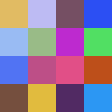

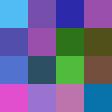

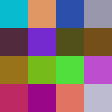

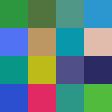

In [15]:
preview_images = []
preview_labels = []
for idx in range(min(4, len(dataset))):
    image, label = dataset[idx]
    preview_images.append(image)
    preview_labels.append(int(label))

preview_path = preview_config.output_dir.parent / "dataset_preview.png"
save_image_grid(
    torch.stack(preview_images),
    torch.tensor(preview_labels, dtype=torch.long),
    dataset.condition_names,
    preview_path,
)
saved_preview_files = sorted(preview_path.parent.glob(f"{preview_path.stem}*.png"))
print("preview base:", preview_path)
print("preview files:", [path.name for path in saved_preview_files])
for path in saved_preview_files[:4]:
    with Image.open(path) as image:
        display(image.copy())


## Memory Cleanup

This helper removes named notebook variables and clears Python, CUDA, and MPS caches. The training loop below calls it between the two guided model runs.

In [16]:
def mem_cleanup(*names: str) -> None:
    for name in names:
        globals().pop(name, None)
    cleanup_torch_resources()
    print("memory cleanup completed")


## Smoke Training

The default smoke run is intentionally short and runs on CPU. It executes both guidance modes in order and runs memory cleanup between model runs. Each run writes a checkpoint, `condition_to_idx.json`, `train_config.json`, `beta_schedule.json`, and generated sample files under its mode-specific output directory.

In [17]:
RUN_SMOKE_TRAIN = True

mem_cleanup("dataset", "preview_images", "preview_labels")
smoke_results = {}

if RUN_SMOKE_TRAIN:
    for index, guidance_mode in enumerate(GUIDANCE_MODES):
        print(f"\n=== smoke run: {guidance_mode} ===")
        smoke_results[guidance_mode] = train_guided_conditional_diffusion(
            smoke_configs[guidance_mode]
        )
        print(smoke_results[guidance_mode])
        if index < len(GUIDANCE_MODES) - 1:
            print(f"\n=== cleanup after {guidance_mode} ===")
            mem_cleanup()
    print("\n=== final cleanup after smoke runs ===")
    mem_cleanup()
else:
    print("Set RUN_SMOKE_TRAIN = True to run both guided smoke training paths.")


memory cleanup completed

=== smoke run: classifier-free ===
[reshape] mode=height-flatten source=448x28 img_size=28x28 blocks=16 (4x4) output=112x112 channels=3
dataset=256 images conditions=256 guidance_mode=classifier-free guidance_scale=2.0 label_source=final-hash steps=3 epochs=None device=cpu beta_schedule=linear diffusion_timesteps=4 sample_image_shape=(3, 112, 112) output=/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook/classifier_free/smoke
step=000001 diffusion_loss=1.099676
step=000002 diffusion_loss=1.094802
step=000003 diffusion_loss=1.080452
{'dataset_size': 256, 'num_conditions': 256, 'guidance_mode': 'classifier-free', 'guidance_scale': 2.0, 'train_steps': 3, 'final_loss': 1.0804518461227417, 'final_classifier_loss': None, 'checkpoint': PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook/classifier_free/smoke/checkpoints/step_000003.pt'), 'sample_gri

## Smoke Outputs


=== outputs: classifier-free ===
checkpoint: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook/classifier_free/smoke/checkpoints/step_000003.pt
sample grid: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook/classifier_free/smoke/samples/final.png
source grid: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook/classifier_free/smoke/samples/final.source.png
source+generated grid: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook/classifier_free/smoke/samples/final.with_source.png
train_config: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook/classifier_free/smoke/train_config.json
condition_to_idx: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook/classifie

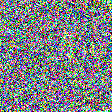

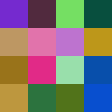

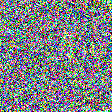

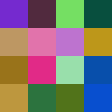


=== outputs: classifier ===
checkpoint: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook/classifier/smoke/checkpoints/step_000003.pt
sample grid: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook/classifier/smoke/samples/final.png
source grid: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook/classifier/smoke/samples/final.source.png
source+generated grid: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook/classifier/smoke/samples/final.with_source.png
train_config: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook/classifier/smoke/train_config.json
condition_to_idx: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_notebook/classifier/smoke/condition_to_idx.json


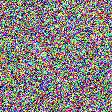

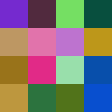

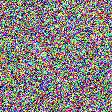

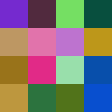

In [18]:
if not smoke_results:
    print("Smoke training has not run yet.")

for guidance_mode, smoke_result in smoke_results.items():
    smoke_config = smoke_configs[guidance_mode]
    print(f"\n=== outputs: {guidance_mode} ===")
    print("checkpoint:", smoke_result["checkpoint"])
    print("sample grid:", smoke_result["sample_grid"])
    print("source grid:", smoke_result["sample_source_grid"])
    print("source+generated grid:", smoke_result["sample_with_source_grid"])

    train_config_path = smoke_config.output_dir / "train_config.json"
    condition_map_path = smoke_config.output_dir / "condition_to_idx.json"
    labels_path = Path(smoke_result["sample_grid"]).with_suffix(".labels.json")

    print("train_config:", train_config_path)
    print("condition_to_idx:", condition_map_path)
    print("sample labels:", labels_path)
    print(json.loads(train_config_path.read_text(encoding="utf-8")))

    sample_path = Path(smoke_result["sample_grid"])
    sample_files = sorted(sample_path.parent.glob(f"{sample_path.stem}*.png"))
    for path in sample_files[:4]:
        with Image.open(path) as image:
            display(image.copy())


## Full Training Configs

The following cells build full-run configs for each guidance mode. `RUN_FULL_TRAIN` defaults to `False` to avoid starting long runs accidentally. When enabled, both full configs run sequentially with memory cleanup between them.

In [19]:
cfg_full_config = replace(
    smoke_configs["classifier-free"],
    guidance_mode="classifier-free",
    guidance_scale=2.0,
    condition_dropout=0.1,
    output_dir=FULL_OUTPUT_ROOTS["classifier-free"],
    image_size=64,
    max_images=None,
    batch_size=32,
    train_steps=1000,
    epochs=1,
    timesteps=200,
    base_channels=64,
    time_dim=256,
    sample_count=16,
    device="auto",
    log_every=50,
)

classifier_full_config = replace(
    smoke_configs["classifier"],
    guidance_mode="classifier",
    guidance_scale=1.0,
    output_dir=FULL_OUTPUT_ROOTS["classifier"],
    image_size=64,
    max_images=None,
    batch_size=32,
    train_steps=1000,
    epochs=1,
    timesteps=200,
    base_channels=64,
    time_dim=256,
    classifier_base_channels=32,
    classifier_learning_rate=2e-4,
    sample_count=16,
    device="auto",
    log_every=50,
)

full_configs = {
    "classifier-free": cfg_full_config,
    "classifier": classifier_full_config,
}

print("classifier-free output:", cfg_full_config.output_dir)
print("classifier output:", classifier_full_config.output_dir)


classifier-free output: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_classifier_free
classifier output: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_classifier


In [20]:
RUN_FULL_TRAIN = True
FULL_TRAIN_MODES = GUIDANCE_MODES

full_results = {}

if RUN_FULL_TRAIN:
    for index, guidance_mode in enumerate(FULL_TRAIN_MODES):
        print(f"\n=== full run: {guidance_mode} ===")
        full_results[guidance_mode] = train_guided_conditional_diffusion(
            full_configs[guidance_mode]
        )
        print(full_results[guidance_mode])
        if index < len(FULL_TRAIN_MODES) - 1:
            print(f"\n=== cleanup after {guidance_mode} ===")
            mem_cleanup()
    print("\n=== final cleanup after full runs ===")
    mem_cleanup()
else:
    print("Set RUN_FULL_TRAIN = True to start both full guided runs.")
    {mode: asdict(config) for mode, config in full_configs.items()}



=== full run: classifier-free ===
[reshape] mode=height-flatten source=448x28 img_size=28x28 blocks=16 (4x4) output=112x112 channels=3
dataset=10000 images conditions=10000 guidance_mode=classifier-free guidance_scale=2.0 label_source=final-hash steps=313 epochs=1 device=mps beta_schedule=linear diffusion_timesteps=200 sample_image_shape=(3, 112, 112) output=/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/guided_conditional_diffusion_classifier_free
step=000001 diffusion_loss=1.115664
step=000050 diffusion_loss=0.134723
step=000100 diffusion_loss=0.067207
step=000150 diffusion_loss=0.065249
step=000200 diffusion_loss=0.050272
step=000250 diffusion_loss=0.041117
step=000300 diffusion_loss=0.025058
step=000313 diffusion_loss=0.024053
{'dataset_size': 10000, 'num_conditions': 10000, 'guidance_mode': 'classifier-free', 'guidance_scale': 2.0, 'train_steps': 313, 'final_loss': 0.02405288629233837, 'final_classifier_loss': None, 'checkpoint': PosixPath('/Users/choisoonwoo